# Assignment 12: Glass Classification using Random Forest

**Name:** Tausif Ali  
**Batch:** Data Science Weekday – Hyderabad  
**Topic:** Random Forest Classification

## Problem Understanding

In this assignment, we are working on the Glass dataset to classify different types of glass based on their chemical composition. Glass classification is important in fields such as forensics, manufacturing, and quality control. For example, identifying the type of glass found at a crime scene can help investigators understand the origin of the material.

The dataset contains features such as refractive index and concentrations of elements like sodium, magnesium, aluminum, silicon, potassium, calcium, barium, and iron. The target variable represents different categories of glass, such as building windows, containers, tableware, and headlamps.

Our objective is to build a Random Forest classification model to accurately classify the type of glass based on these features. Random Forest is an ensemble learning method that improves prediction accuracy by combining multiple decision trees.

## Importing Required Libraries

In this step, we import all the necessary libraries required for data analysis and model building. Pandas and NumPy are used for handling data, while Matplotlib and Seaborn are used for visualization.

Scikit-learn provides tools for machine learning tasks such as model training, evaluation, and hyperparameter tuning. These libraries help us perform all steps efficiently, from data loading to model evaluation.

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Loading the Dataset

In this step, we load the Glass dataset into the notebook using pandas. The dataset contains various chemical properties of glass samples along with their type classification.

After loading the dataset, we display the first few rows to understand its structure. This helps us identify the column names, feature values, and the target variable.

Proper loading of the dataset ensures that the data is correctly imported and ready for further analysis and preprocessing.

In [82]:
glass = fetch_openml(name='glass', version=1, as_frame=True)
df = glass.frame

df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.51793,12.79,3.50,1.12,73.03,0.64,8.77,0.0,0.00,build wind float
1,1.51643,12.16,3.52,1.35,72.89,0.57,8.53,0.0,0.00,vehic wind float
2,1.51793,13.21,3.48,1.41,72.64,0.59,8.43,0.0,0.00,build wind float
3,1.51299,14.40,1.74,1.54,74.55,0.00,7.59,0.0,0.00,tableware
4,1.53393,12.30,0.00,1.00,70.16,0.12,16.19,0.0,0.24,build wind non-float


## Data Understanding

In this step, we explore the dataset to understand its structure and characteristics. The info() function provides details about column names, data types, and non-null values, helping us identify missing values.

The describe() function gives statistical information such as mean, standard deviation, minimum, and maximum values. This helps in understanding the distribution of the data.

Checking for missing values is also important, as it ensures that the dataset is clean and ready for further analysis and model building.

In [83]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   RI      214 non-null    float64 
 1   Na      214 non-null    float64 
 2   Mg      214 non-null    float64 
 3   Al      214 non-null    float64 
 4   Si      214 non-null    float64 
 5   K       214 non-null    float64 
 6   Ca      214 non-null    float64 
 7   Ba      214 non-null    float64 
 8   Fe      214 non-null    float64 
 9   Type    214 non-null    category
dtypes: category(1), float64(9)
memory usage: 15.6 KB


RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

## Exploratory Data Analysis (EDA)

EDA helps us understand the distribution and patterns present in the dataset. We use histograms to visualize how values are distributed across different features. This helps in identifying whether the data is normally distributed or skewed.

We also use box plots to detect outliers in the dataset. Outliers are extreme values that may affect model performance. Identifying and understanding them is important before building the model.

EDA provides valuable insights that help in making informed decisions during preprocessing and model selection.

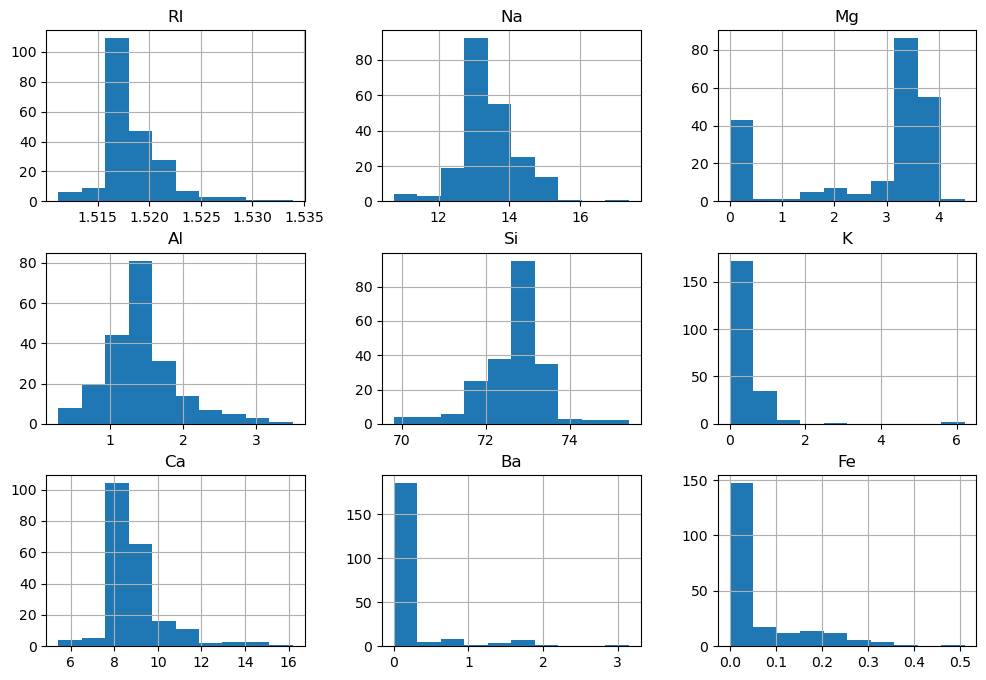

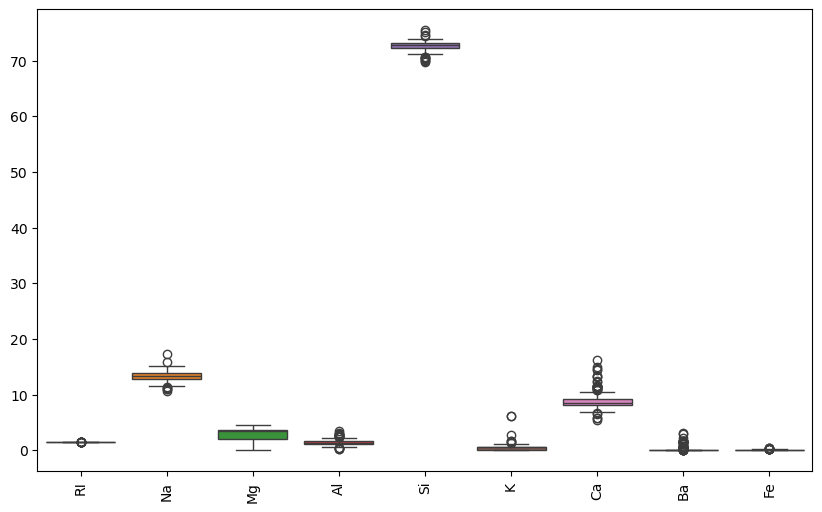

In [84]:
df.hist(figsize=(12,8))
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

## Correlation Analysis

Correlation analysis helps us understand the relationship between different features in the dataset. A heatmap is used to visualize correlation values between variables.

Strong correlations indicate a strong relationship between variables, while weak correlations suggest independence. This helps in identifying important features and understanding how they influence each other.

We use only numerical columns to compute correlation, as correlation calculations require numeric data. This step helps improve model performance and interpretability.

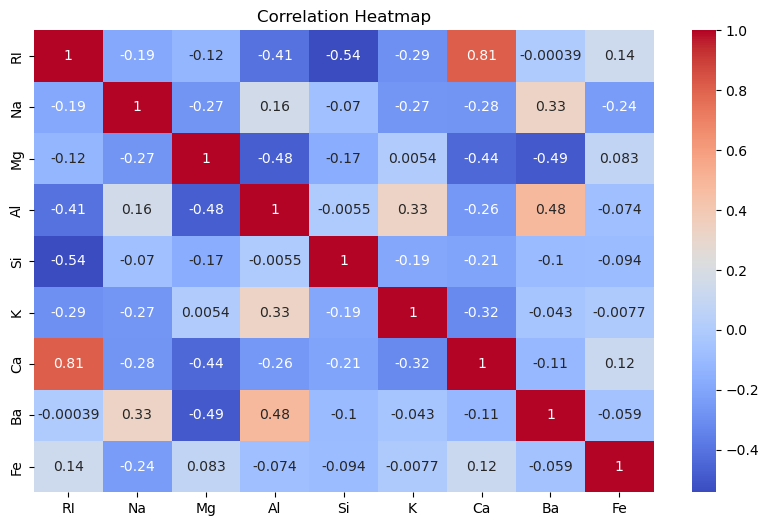

In [85]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Data Preprocessing

In this step, we prepare the dataset for machine learning. We separate the dataset into input features (X) and the target variable (y).

The target variable contains categorical text values representing different types of glass. Since machine learning models require numerical input, we convert these categories into numerical labels using Label Encoding.

This process assigns a unique number to each category, making the data suitable for model training.

In [86]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X = df.drop("Type", axis=1)
y = le.fit_transform(df["Type"])

## Feature Scaling

Feature scaling ensures that all features are on a similar scale. This helps improve model performance and stability.

We use StandardScaler to normalize the feature values.

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

## Train-Test Split

To evaluate the model properly, we split the dataset into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance.

We use an 80-20 split, where 80% of the data is used for training and 20% for testing. This ensures that the model is tested on unseen data, which helps in checking its generalization ability.

A fixed random state is used to ensure reproducibility of results.

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Building (Random Forest)

In this step, we build a Random Forest classifier. Random Forest is an ensemble learning method that combines multiple decision trees to improve accuracy and reduce overfitting.

Each tree in the forest makes a prediction, and the final output is based on majority voting. This makes the model more robust and reliable.

We also use class_weight='balanced' to handle any imbalance in the dataset. The model is trained using the training data and then used to make predictions on the test data.

In [89]:
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Model Evaluation

In this step, we evaluate the performance of the model using different metrics. Accuracy measures the overall correctness of the model, while precision, recall, and F1-score provide deeper insights into performance.

These metrics help us understand how well the model is predicting each class. A good model should have high values for all these metrics.

Evaluating the model is important to ensure that it performs well not only on training data but also on unseen data.

In [90]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8837209302325582
              precision    recall  f1-score   support

           0       0.77      0.91      0.83        11
           1       1.00      0.81      0.89        21
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         1
           5       0.50      1.00      0.67         2

    accuracy                           0.88        43
   macro avg       0.88      0.95      0.90        43
weighted avg       0.92      0.88      0.89        43



## Confusion Matrix

The confusion matrix is used to evaluate the performance of a classification model by comparing actual and predicted values.

It shows how many predictions are correct and where the model makes mistakes. The diagonal values represent correct predictions, while other values indicate misclassifications.

This helps in understanding the performance of the model for each class and identifying areas for improvement.

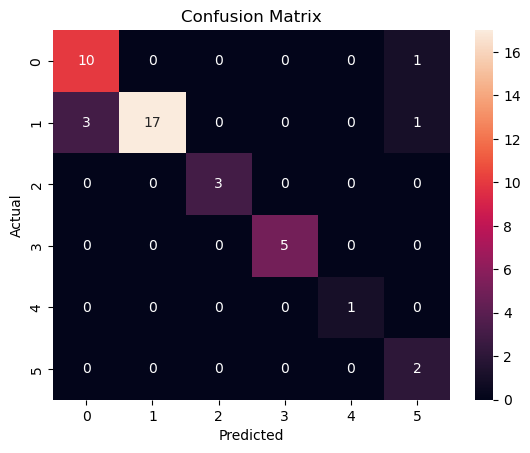

In [91]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

Feature importance helps us understand which features contribute the most to the model’s predictions. Random Forest provides this information based on how much each feature reduces impurity.

By analyzing feature importance, we can identify the most influential variables in the dataset. This helps in improving model understanding and can also be useful for feature selection.

Visualizing feature importance makes it easier to interpret the model.

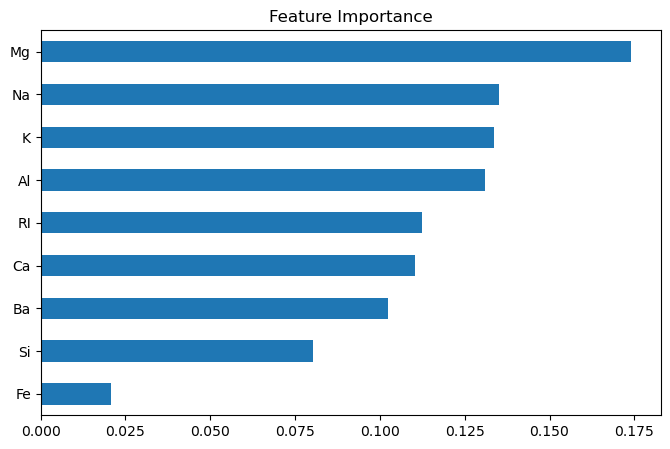

In [92]:
columns = df.drop("Type", axis=1).columns

scaler = StandardScaler()
X = scaler.fit_transform(df.drop("Type", axis=1))

feature_importances = pd.Series(model.feature_importances_, index=columns)

feature_importances.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

## Hyperparameter Tuning

Hyperparameter tuning is used to improve model performance by finding the best combination of parameters. We use GridSearchCV to test different parameter values.

This process helps in optimizing the model and achieving better accuracy. It systematically searches for the best parameters using cross-validation.

Tuning improves model reliability and ensures better performance on unseen data.

In [93]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}


## Bagging vs Boosting

Bagging (Bootstrap Aggregating) reduces variance by training multiple models independently and combining their predictions. Random Forest is an example of bagging.

Boosting reduces bias by training models sequentially, where each new model focuses on correcting the errors of the previous one.

Bagging improves stability, while boosting improves accuracy. Both are important ensemble techniques used in machine learning.

## Handling Imbalance

Class imbalance is handled using class_weight='balanced', which assigns higher weight to minority classes.

## Conclusion

In this assignment, we built a Random Forest classification model to classify different types of glass. We performed data analysis, visualization, and preprocessing to prepare the dataset.

The model achieved good performance and was further improved using hyperparameter tuning. Feature importance helped us understand the key factors influencing predictions.

Overall, this assignment provided practical knowledge of ensemble learning and its real-world applications.